1. Load Dataset
2. Analyse Basic Stats
3. Select Features <br>
~~4. No train test split because in unsupervised learning we don't have target column to train our dataset~~
5. Scale the data
6. Loop over multiple values of K and calculate their final WCSS scoring
7. Plot K v/s WCSS to find the optimal value of K
8. Use optimal value of K
9. Initialize K_means object with selected K
10. Fit the data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
dfX = pd.read_csv("./Mall_Customers.csv")
dfX.shape

(200, 5)

In [3]:
dfX.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
dfX.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
dfX.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
dfX.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
dfX.groupby("Gender")['CustomerID'].count()

Gender
Female    112
Male       88
Name: CustomerID, dtype: int64

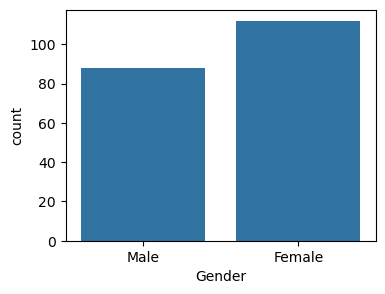

In [8]:
plt.figure(figsize=(4,3))
sns.countplot(data=dfX, x="Gender")
plt.show()

In [9]:
# First Separating the df
df = dfX.copy()
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
# Here the Customer Id represents index of each row so drop the feature
df.drop(columns=["CustomerID"],inplace=True)

In [11]:
# Gender is a categorical data -> requires label encoding
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [12]:
df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,0.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


> The above data needs to be scaled before training the model

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled[0:5]

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992]])

> WCSS (Within-Cluster Sum of Squares), also called inertia, is the total squared distance between each data point in a cluster and that cluster's central point, or centroid.
$$
\mathrm{WCSS} = \sum_{i=1}^{k} \sum_{x \in C_i} \|x-\mu_i\|^2
$$
- **$k$**: The total number of clusters.
- **$C_i$**: The i-th cluster.
- **$x$**: A specific data point belonging to cluster $C_i$.
- **$\mu_i$**: The centroid (mean point) of cluster $C_i$.
- **$\|x-\mu_i\|^2$**: The squared Euclidean distance between data point $x$ and its cluster centroid $\mu_i$.

In [14]:
wcss = [] 
k_range = range(1,30)

- init defines how centroids are initialized before iterations begin.
- "k-means++" chooses the first centroid randomly, then subsequent centroids farther away from already chosen ones.
- n_init = 10 runs Kmeans 10 times each with different random centroid starting points, and picks the best.

In [15]:
for k in k_range:
    kmeans = KMeans(n_clusters=k,init='k-means++',random_state=20,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

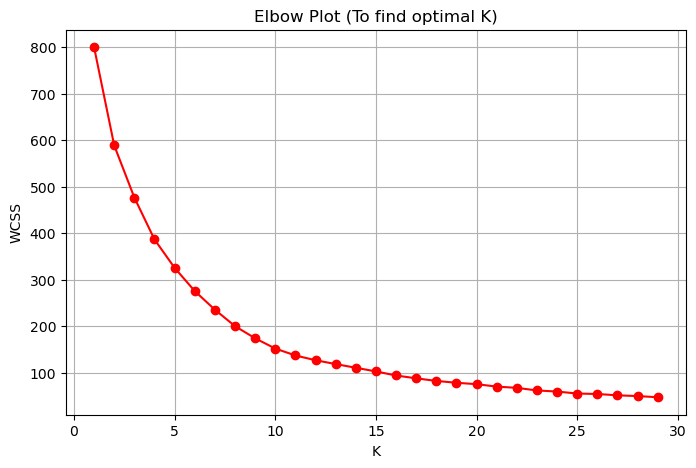

In [16]:
plt.figure(figsize=(8,5))
plt.title("Elbow Plot (To find optimal K)")
plt.plot(k_range,wcss,'ro-')
plt.xlabel("K")
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [17]:
k_optimal  = 5 # how to decide this -> first there are maximum gaps between 1 -> 2 , 2 -> 3 , 3 -> 4 
#                                   -> Then there the gap between 4 -> 5 and 5 -> 6  are almost same, hence the optimal i decide  5

In [18]:
kmeans_final = KMeans(n_clusters=k_optimal,init='k-means++',random_state=20,n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_scaled)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,4
1,1,21,15,81,4
2,0,20,16,6,2
3,0,23,16,77,1
4,0,31,17,40,2


In [19]:
kmeans_final.cluster_centers_     # it will show the 5 cluster centroids in 4D (Gender, Age, Annual_Income, Spending_Score)

array([[ 1.12815215,  1.22385356, -0.4498575 , -0.44231533],
       [-0.88640526, -0.75047453, -0.00501655,  0.6979562 ],
       [-0.88640526,  0.73155219, -0.44455768, -0.50400513],
       [ 0.38201978,  0.03202921,  1.20287422, -1.31619469],
       [ 1.12815215, -0.76072691,  0.05496398,  0.83369302]])

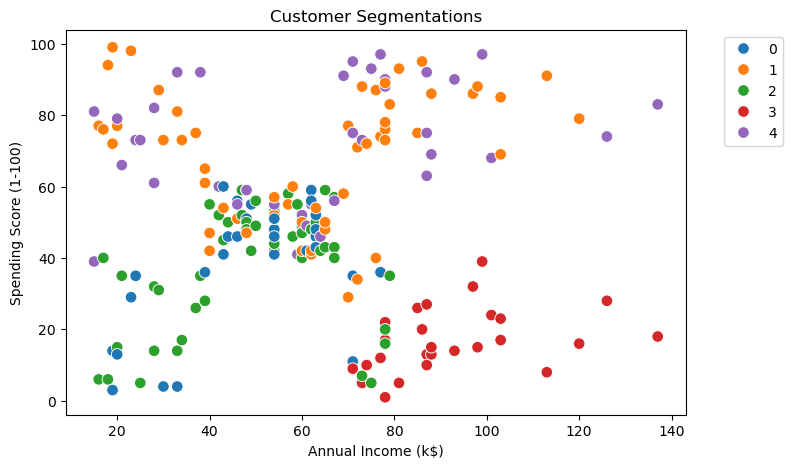

In [20]:
# But it's not possible for us/human to see 4D so let's view it in 2D : means 2 features
plt.figure(figsize=(8,5))
plt.title("Customer Segmentations")
sns.scatterplot(data=df,x="Annual Income (k$)",y="Spending Score (1-100)", hue= 'Cluster',
                s=70,palette='tab10')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True)
plt.show()


> **⚠️ Important Correction:**  
>
> The biggest mistake in the above graph is that we directly visualized the data in **2D without performing feature reduction**. However, the clustering was performed using **4-dimensional data**.
>
> Since a **4D dataset cannot be directly visualized in 2D**, we first need to reduce the dimensionality from **4D → 2D** while preserving as much meaningful information as possible.
>
> This process is called **Dimensionality Reduction**, and **PCA (Principal Component Analysis)** is one of the most commonly used techniques for this purpose.

In [21]:
pca = PCA(n_components=2) # because we need our 4D data in 2D
x_pca = pca.fit_transform(X_scaled)
x_pca[0:5]

array([[-0.40638272, -0.52071363],
       [-1.42767287, -0.3673102 ],
       [ 0.05076057, -1.89406774],
       [-1.6945131 , -1.63190805],
       [-0.31310838, -1.81048272]])

In [22]:
df['PCA1'] = x_pca[:,0]
df['PCA2'] = x_pca[:,1] 
df.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,PCA1,PCA2
0,1,19,15,39,4,-0.406383,-0.520714
1,1,21,15,81,4,-1.427673,-0.367310
2,0,20,16,6,2,0.050761,-1.894068
3,0,23,16,77,1,-1.694513,-1.631908
4,0,31,17,40,2,-0.313108,-1.810483
5,0,22,17,76,1,-1.717446,-1.599264
6,0,35,18,6,2,0.790821,-1.947271
7,0,23,18,94,1,-2.148322,-1.505374
8,1,64,19,3,0,2.774286,-0.882988
9,0,30,19,72,1,-1.216295,-1.616405


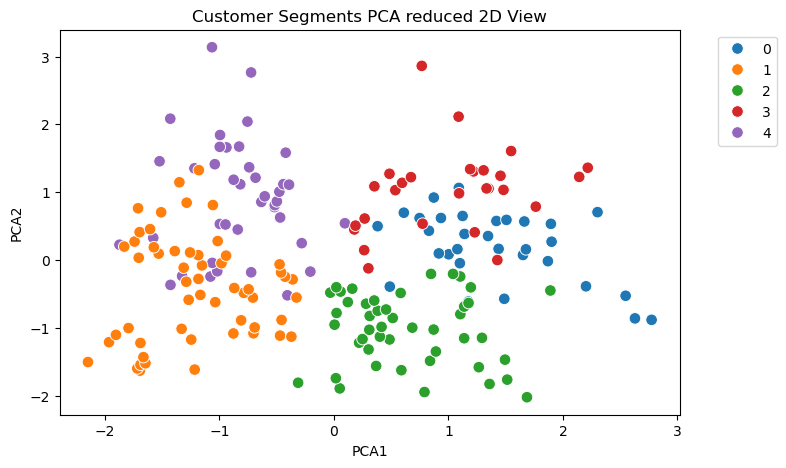

In [23]:
plt.figure(figsize=(8,5))
plt.title("Customer Segments PCA reduced 2D View")
sns.scatterplot(data=df,x=df["PCA1"],y=df["PCA2"], hue= 'Cluster',
                s=70,palette='tab10')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True)
plt.show()

In [24]:
centroids = kmeans_final.cluster_centers_
original_centroids = scaler.inverse_transform(centroids)
original_centroids

array([[ 1.00000000e+00,  5.59032258e+01,  4.87741935e+01,
         3.88064516e+01],
       [-2.77555756e-16,  2.83928571e+01,  6.04285714e+01,
         6.81785714e+01],
       [-1.11022302e-16,  4.90434783e+01,  4.89130435e+01,
         3.72173913e+01],
       [ 6.29629630e-01,  3.92962963e+01,  9.20740741e+01,
         1.62962963e+01],
       [ 1.00000000e+00,  2.82500000e+01,  6.20000000e+01,
         7.16750000e+01]])

In [25]:
df["Cluster"].value_counts()

Cluster
1    56
2    46
4    40
0    31
3    27
Name: count, dtype: int64

In [26]:
df['CustomerID'] = dfX["CustomerID"]
df = df[['CustomerID'] + [col for col in df.columns if col != 'CustomerID']] # to make first column customer id
df.to_csv('./Mall_Customers_Clustered.csv',index=False)

In [27]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,PCA1,PCA2
0,1,1,19,15,39,4,-0.406383,-0.520714
1,2,1,21,15,81,4,-1.427673,-0.367310
2,3,0,20,16,6,2,0.050761,-1.894068
3,4,0,23,16,77,1,-1.694513,-1.631908
4,5,0,31,17,40,2,-0.313108,-1.810483
